In [1]:
import pandas as pd

ruta = "/content/WA_Fn-UseC_-HR-Employee-Attrition.csv"

df = pd.read_csv(ruta)

print("Filas y columnas:", df.shape)

df.head()

Filas y columnas: (1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


# Predicción de rotación de empleados

## 1. Comprensión inicial de los datos

Este proyecto analiza información de 1,470 empleados con el objetivo de identificar patrones asociados con la rotación laboral y construir posteriormente un modelo de clasificación usando scikit-learn.

La variable objetivo es `Attrition`, que indica si el empleado abandonó o permaneció en la empresa.

In [2]:
resumen_columnas = pd.DataFrame({
    "Columna": df.columns,
    "Tipo de dato": df.dtypes.astype(str).values,
    "Valores nulos": df.isnull().sum().values,
    "Valores únicos": df.nunique().values
})

resumen_columnas

,Columna,Tipo de dato,Valores nulos,Valores únicos
0,Age,int64,0,43
1,Attrition,object,0,2
2,BusinessTravel,object,0,3
3,DailyRate,int64,0,886
4,Department,object,0,3
5,DistanceFromHome,int64,0,29
6,Education,int64,0,5
7,EducationField,object,0,6
8,EmployeeCount,int64,0,1
9,EmployeeNumber,int64,0,1470


## 2. Evaluación de la calidad de los datos

Se comprobará la existencia de valores faltantes, registros duplicados, columnas constantes e identificadores que no aportan capacidad predictiva.

In [3]:
# Comprobación de la calidad de los datos

print("Número de empleados:", len(df))
print("Total de valores nulos:", df.isnull().sum().sum())
print("Filas duplicadas:", df.duplicated().sum())

columnas_constantes = [
    columna
    for columna in df.columns
    if df[columna].nunique() == 1
]

print("Columnas constantes:", columnas_constantes)
print(
    "Valores únicos en EmployeeNumber:",
    df["EmployeeNumber"].nunique()
)

Número de empleados: 1470
Total de valores nulos: 0
Filas duplicadas: 0
Columnas constantes: ['EmployeeCount', 'Over18', 'StandardHours']
Valores únicos en EmployeeNumber: 1470


## 3. Análisis de la variable objetivo

La variable `Attrition` indica si el empleado abandonó la empresa (`Yes`) o permaneció en ella (`No`). Se analizarán las cantidades y porcentajes de ambas categorías.

In [4]:
# Cantidad y porcentaje de empleados por categoría

conteo_rotacion = df["Attrition"].value_counts()

porcentaje_rotacion = (
    df["Attrition"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

resumen_rotacion = pd.DataFrame({
    "Cantidad": conteo_rotacion,
    "Porcentaje": porcentaje_rotacion
})

resumen_rotacion

,Cantidad,Porcentaje
Attrition,,
No,1233,83.88
Yes,237,16.12


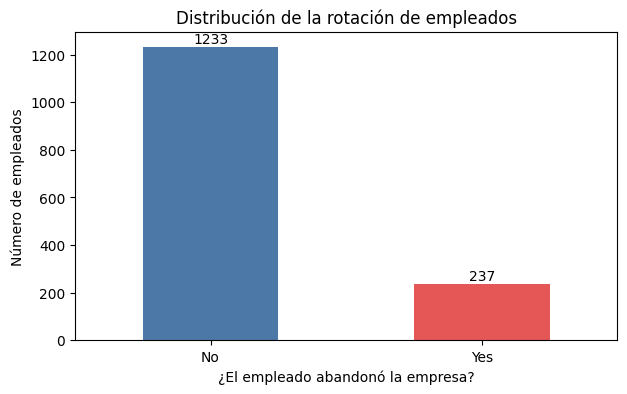

In [5]:
import matplotlib.pyplot as plt

colores = ["#4C78A8", "#E45756"]

ax = conteo_rotacion.plot(
    kind="bar",
    color=colores,
    figsize=(7, 4)
)

ax.bar_label(ax.containers[0])

plt.title("Distribución de la rotación de empleados")
plt.xlabel("¿El empleado abandonó la empresa?")
plt.ylabel("Número de empleados")
plt.xticks(rotation=0)
plt.show()

## 4. Rotación y horas extra

Se analizará si los empleados que trabajan horas extra presentan una tasa de rotación diferente. Se utilizarán porcentajes porque los grupos no tienen la misma cantidad de empleados.

In [6]:
# Rotación según realización de horas extra

tabla_horas_extra = pd.crosstab(
    df["OverTime"],
    df["Attrition"]
)

tabla_horas_extra["Total"] = tabla_horas_extra.sum(axis=1)

tabla_horas_extra["Tasa de rotación (%)"] = (
    tabla_horas_extra["Yes"]
    / tabla_horas_extra["Total"]
    * 100
).round(2)

tabla_horas_extra

Attrition,No,Yes,Total,Tasa de rotación (%)
OverTime,,,,
No,944,110,1054,10.44
Yes,289,127,416,30.53


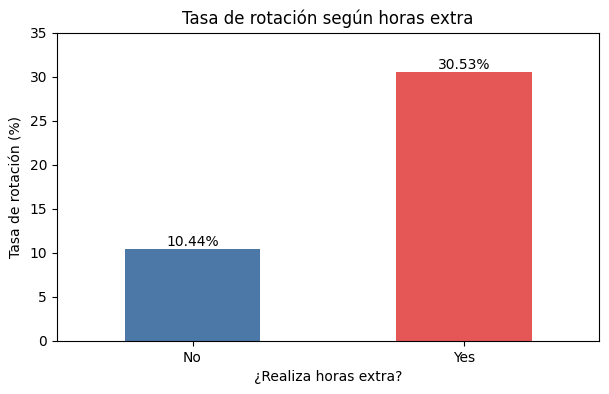

In [7]:
ax = tabla_horas_extra["Tasa de rotación (%)"].plot(
    kind="bar",
    color=["#4C78A8", "#E45756"],
    figsize=(7, 4)
)

ax.bar_label(
    ax.containers[0],
    fmt="%.2f%%"
)

plt.title("Tasa de rotación según horas extra")
plt.xlabel("¿Realiza horas extra?")
plt.ylabel("Tasa de rotación (%)")
plt.xticks(rotation=0)
plt.ylim(0, 35)
plt.show()

## 5. Rotación según frecuencia de viajes

Se comparará la tasa de rotación entre empleados que no viajan, viajan ocasionalmente y viajan frecuentemente.

In [8]:
# Tasa de rotación según frecuencia de viajes

rotacion_viajes = (
    df.groupby("BusinessTravel")["Attrition"]
    .apply(lambda valores: (valores == "Yes").mean() * 100)
    .round(2)
    .sort_values()
)

rotacion_viajes

,Attrition
BusinessTravel,
Non-Travel,8.00
Travel_Rarely,14.96
Travel_Frequently,24.91


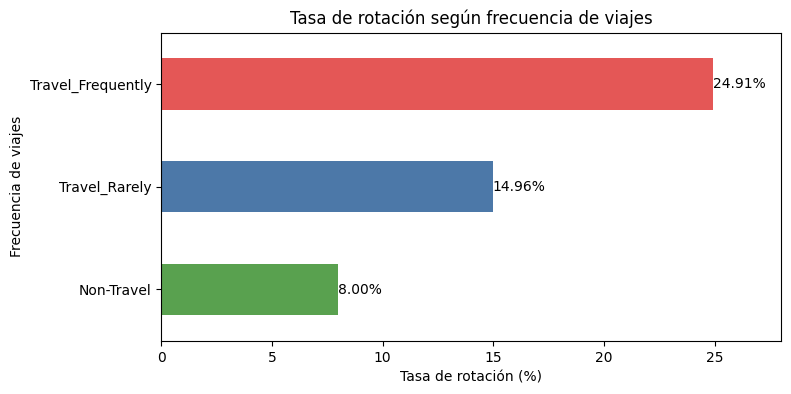

In [9]:
ax = rotacion_viajes.plot(
    kind="barh",
    color=["#59A14F", "#4C78A8", "#E45756"],
    figsize=(8, 4)
)

ax.bar_label(
    ax.containers[0],
    fmt="%.2f%%"
)

plt.title("Tasa de rotación según frecuencia de viajes")
plt.xlabel("Tasa de rotación (%)")
plt.ylabel("Frecuencia de viajes")
plt.xlim(0, 28)
plt.show()

## 6. Satisfacción laboral y equilibrio trabajo-vida

Se analizará si los niveles de satisfacción laboral y equilibrio entre vida personal y trabajo presentan diferentes tasas de rotación.

In [10]:
# Función para calcular rotación por categoría

def resumen_rotacion_por(variable):
    resumen = df.groupby(variable).agg(
        Empleados=("Attrition", "size"),
        Rotaciones=("Attrition", lambda valores: (valores == "Yes").sum())
    )

    resumen["Tasa de rotación (%)"] = (
        resumen["Rotaciones"]
        / resumen["Empleados"]
        * 100
    ).round(2)

    return resumen

In [11]:
rotacion_satisfaccion = resumen_rotacion_por(
    "JobSatisfaction"
)

rotacion_satisfaccion

,Empleados,Rotaciones,Tasa de rotación (%)
JobSatisfaction,,,
1,289,66,22.84
2,280,46,16.43
3,442,73,16.52
4,459,52,11.33


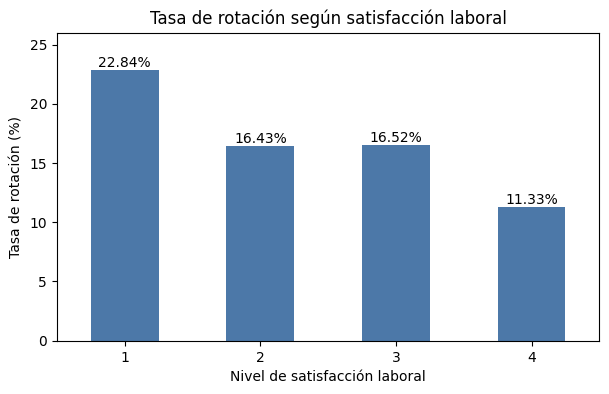

In [12]:
ax = rotacion_satisfaccion["Tasa de rotación (%)"].plot(
    kind="bar",
    color="#4C78A8",
    figsize=(7, 4)
)

ax.bar_label(
    ax.containers[0],
    fmt="%.2f%%"
)

plt.title("Tasa de rotación según satisfacción laboral")
plt.xlabel("Nivel de satisfacción laboral")
plt.ylabel("Tasa de rotación (%)")
plt.xticks(rotation=0)
plt.ylim(0, 26)
plt.show()

In [13]:
rotacion_equilibrio = resumen_rotacion_por(
    "WorkLifeBalance"
)

rotacion_equilibrio

,Empleados,Rotaciones,Tasa de rotación (%)
WorkLifeBalance,,,
1,80,25,31.25
2,344,58,16.86
3,893,127,14.22
4,153,27,17.65


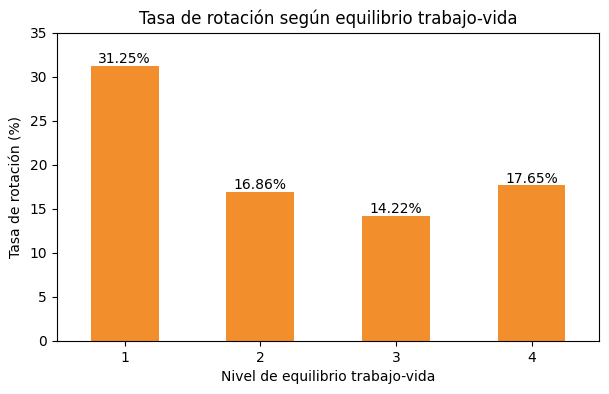

In [14]:
ax = rotacion_equilibrio["Tasa de rotación (%)"].plot(
    kind="bar",
    color="#F28E2B",
    figsize=(7, 4)
)

ax.bar_label(
    ax.containers[0],
    fmt="%.2f%%"
)

plt.title("Tasa de rotación según equilibrio trabajo-vida")
plt.xlabel("Nivel de equilibrio trabajo-vida")
plt.ylabel("Tasa de rotación (%)")
plt.xticks(rotation=0)
plt.ylim(0, 35)
plt.show()

## 7. Análisis de variables numéricas

Se compararán la edad, el ingreso mensual, la antigüedad, la experiencia laboral y la distancia desde el hogar entre quienes permanecieron y quienes abandonaron la empresa.

In [15]:
variables_numericas = [
    "Age",
    "MonthlyIncome",
    "YearsAtCompany",
    "TotalWorkingYears",
    "DistanceFromHome"
]

medianas_por_rotacion = (
    df.groupby("Attrition")[variables_numericas]
    .median()
    .round(2)
)

medianas_por_rotacion

,Age,MonthlyIncome,YearsAtCompany,TotalWorkingYears,DistanceFromHome
Attrition,,,,,
No,36.0,5204.0,6.0,10.0,7.0
Yes,32.0,3202.0,3.0,7.0,9.0


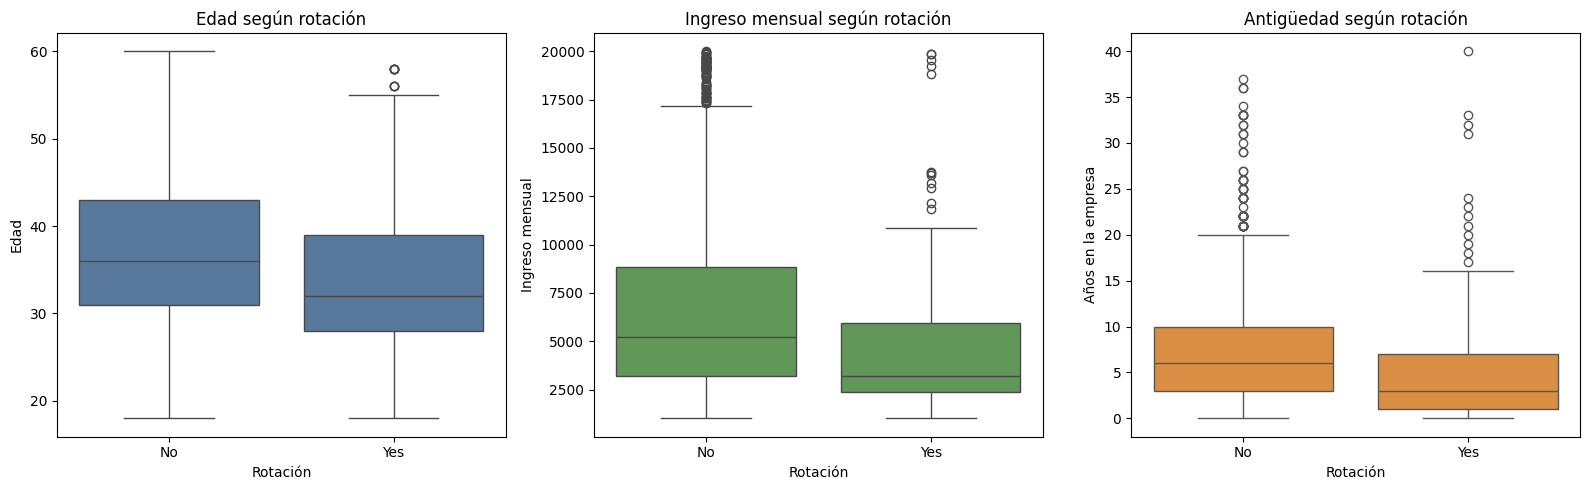

In [16]:
import seaborn as sns

fig, axes = plt.subplots(
    1,
    3,
    figsize=(16, 5)
)

sns.boxplot(
    data=df,
    x="Attrition",
    y="Age",
    order=["No", "Yes"],
    color="#4C78A8",
    ax=axes[0]
)

axes[0].set_title("Edad según rotación")
axes[0].set_xlabel("Rotación")
axes[0].set_ylabel("Edad")

sns.boxplot(
    data=df,
    x="Attrition",
    y="MonthlyIncome",
    order=["No", "Yes"],
    color="#59A14F",
    ax=axes[1]
)

axes[1].set_title("Ingreso mensual según rotación")
axes[1].set_xlabel("Rotación")
axes[1].set_ylabel("Ingreso mensual")

sns.boxplot(
    data=df,
    x="Attrition",
    y="YearsAtCompany",
    order=["No", "Yes"],
    color="#F28E2B",
    ax=axes[2]
)

axes[2].set_title("Antigüedad según rotación")
axes[2].set_xlabel("Rotación")
axes[2].set_ylabel("Años en la empresa")

plt.tight_layout()
plt.show()

## 8. Conclusiones del análisis exploratorio

- El conjunto contiene 1,470 empleados y 35 variables.
- No existen valores faltantes ni registros duplicados.
- El 16.12% de los empleados abandonó la empresa.
- La variable objetivo está desbalanceada.
- La rotación fue considerablemente mayor entre quienes realizaban horas extra.
- Los viajes frecuentes también estuvieron asociados con una mayor rotación.
- La menor satisfacción laboral presentó una rotación más elevada.
- El nivel más bajo de equilibrio trabajo-vida presentó la mayor tasa de rotación.
- Quienes abandonaron mostraron menores medianas de edad, ingreso y antigüedad.
- Las distribuciones se superponen, por lo que ninguna variable individual permite predecir la rotación con suficiente seguridad.
- Estos resultados representan asociaciones y no demuestran relaciones causales.

## 9. Preparación del conjunto para modelado

Se eliminarán las columnas constantes y el identificador único del empleado. La variable objetivo se convertirá a valores binarios: `Yes = 1` y `No = 0`.

In [17]:
# Crear una copia para el modelado

df_modelo = df.copy()

columnas_eliminar = [
    "EmployeeCount",
    "EmployeeNumber",
    "Over18",
    "StandardHours"
]

df_modelo = df_modelo.drop(
    columns=columnas_eliminar
)

df_modelo["Attrition"] = (
    df_modelo["Attrition"]
    .map({
        "No": 0,
        "Yes": 1
    })
)

print("Dimensiones originales:", df.shape)
print("Dimensiones para modelado:", df_modelo.shape)
print()
print("Tipo de Attrition:", df_modelo["Attrition"].dtype)
print()
print(df_modelo["Attrition"].value_counts())

Dimensiones originales: (1470, 35)
Dimensiones para modelado: (1470, 31)

Tipo de Attrition: int64

Attrition
0    1233
1     237
Name: count, dtype: int64


In [18]:
ruta_salida = "/content/employee_attrition_limpio.csv"

df_modelo.to_csv(
    ruta_salida,
    index=False
)

print("Archivo guardado en:", ruta_salida)

Archivo guardado en: /content/employee_attrition_limpio.csv


In [19]:
from google.colab import files

files.download(ruta_salida)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>